**Univariate Exploratory Data Analysis of NBA Dataset**

This analysis includes:

Data validation, summary statistics (mean, median, variance, skewness, kurtosis, etc.), and visualizations (histograms, bar graphs, ECDF functions).
The goal is to provide a clear overview of the NBA dataset being used.


**Data Source**

The dataset is the NBA dataset file our team is using, which contains data scraped and cleaned from  https://www.basketball-reference.com/leagues on September 8, 2025. Data source used for EDA on September 13, 2025.  

Saving nba_data.csv to nba_data (1).csv
=== DATA VALIDATION ===
Dataset contains 70905 rows and 8 columns.

Missing Values Summary:
           Missing Values  Percent of Total (%)
season                  0                   0.0
date                    0                   0.0
team1                   0                   0.0
team2                   0                   0.0
result                  0                   0.0
score1                  0                   0.0
score2                  0                   0.0
home_away               0                   0.0 

Column names in dataset:
['season', 'date', 'team1', 'team2', 'result', 'score1', 'score2', 'home_away'] 

Number of duplicate rows: 0

=== DESCRIPTIVE STATISTICS ===
Numeric Variables Summary (score1, score2):
          Count        Mean  Median   Mode    Std Dev    Variance  Skewness  \
score1  70905.0  105.646259   105.0  106.0  14.396336  207.254477  0.072513   
score2  70905.0  102.163345   102.0  103.0  14.069012  197.937100

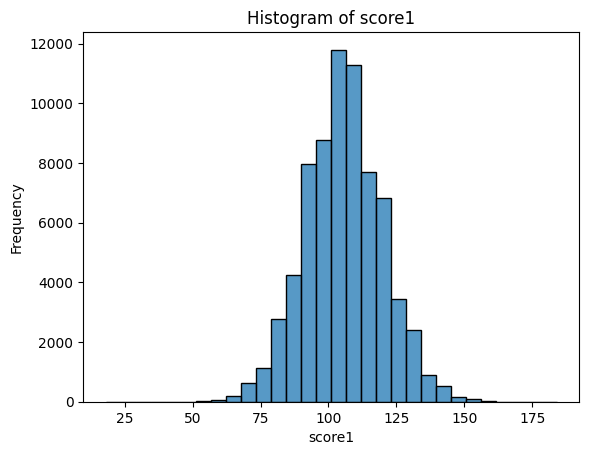

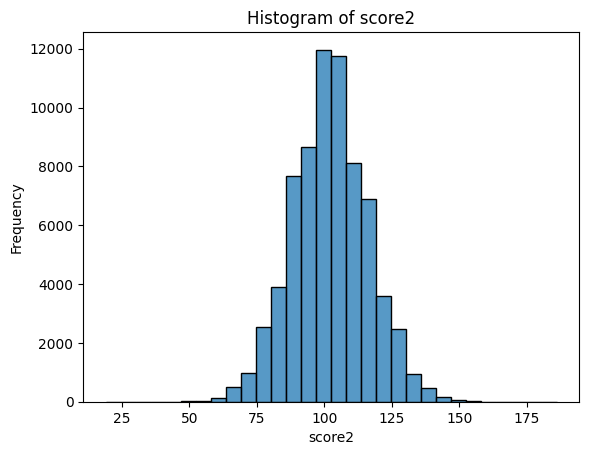

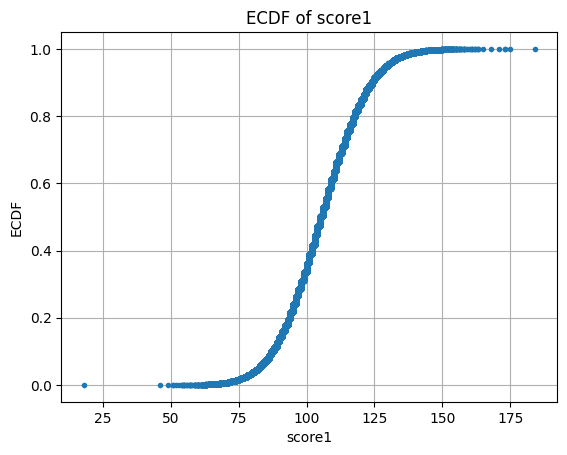

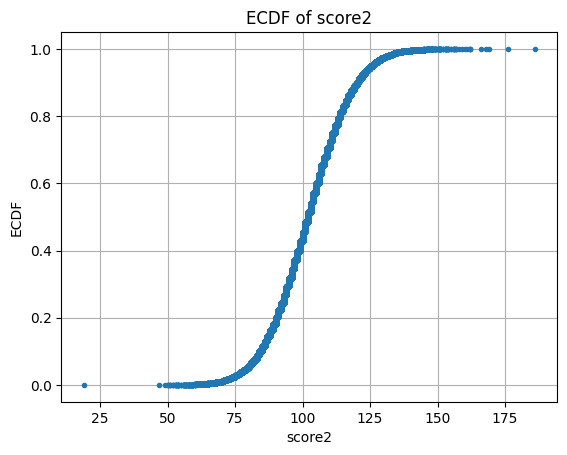

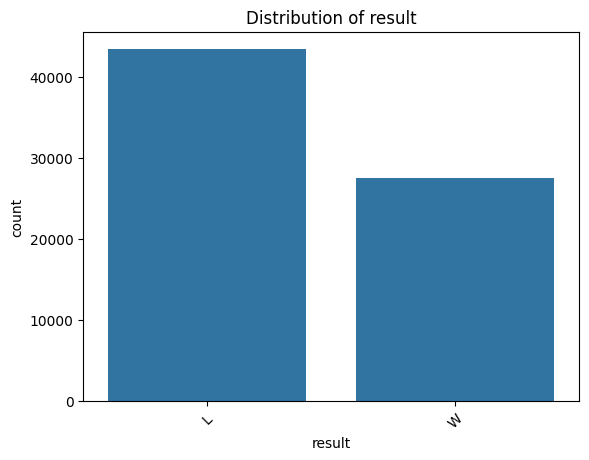

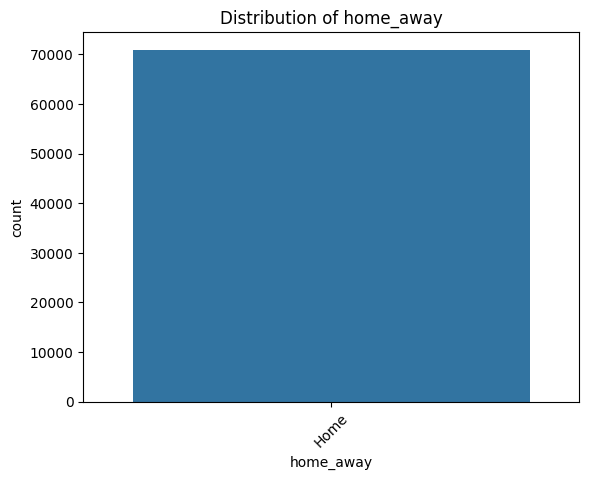

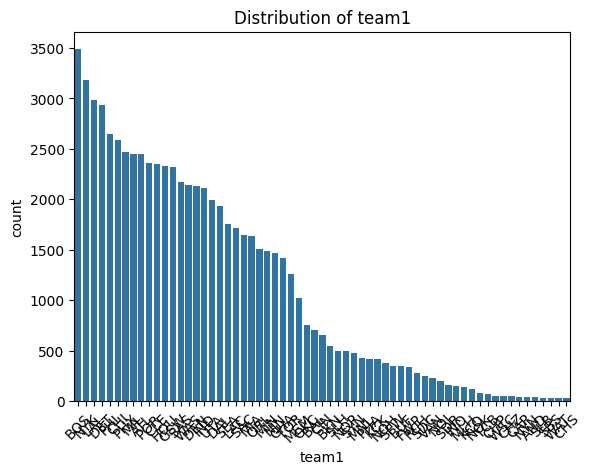

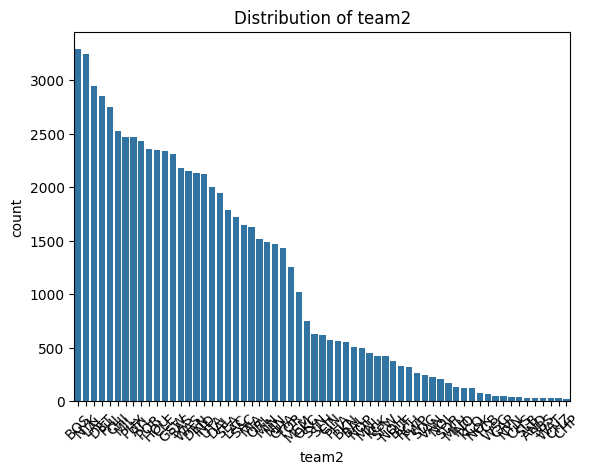

In [2]:
from google.colab import files
import pandas as pd

# Upload file manually
uploaded = files.upload()

# Load the dataset
df = pd.read_csv("nba_data.csv")

# Preview
df.head()



# =============================
# Univariate EDA - NBA Dataset
# =============================

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, mode

# Load dataset
# (adjust path if uploading via Colab files)
df = pd.read_csv("nba_data.csv")

# ==================================================
# SECTION 1: Data Validation
# ==================================================

print("=== DATA VALIDATION ===")

# Dataset dimensions
rows, cols = df.shape
print(f"Dataset contains {rows} rows and {cols} columns.\n")

# Missing values count and percentage
na_counts = df.isna().sum()
na_percent = (na_counts / len(df)) * 100
na_summary = pd.DataFrame({
    "Missing Values": na_counts,
    "Percent of Total (%)": na_percent
})
print("Missing Values Summary:")
print(na_summary, "\n")

# Verify column names are standardized
print("Column names in dataset:")
print(df.columns.tolist(), "\n")

# Check no duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}\n")

# ==================================================
# SECTION 2: Descriptive Statistics
# ==================================================

print("=== DESCRIPTIVE STATISTICS ===")

# ---- NUMERIC VARIABLES ----
numeric_cols = ['score1', 'score2']
desc_stats = {}

for col in numeric_cols:
    data = df[col]
    desc_stats[col] = {
        "Count": data.count(),
        "Mean": data.mean(),
        "Median": data.median(),
        "Mode": data.mode().iloc[0] if not data.mode().empty else np.nan,
        "Std Dev": data.std(),
        "Variance": data.var(),
        "Skewness": skew(data),
        "Kurtosis": kurtosis(data),
        "Min": data.min(),
        "Max": data.max(),
        "Q1": data.quantile(0.25),
        "Q2 (Median)": data.quantile(0.50),
        "Q3": data.quantile(0.75),
        "IQR": data.quantile(0.75) - data.quantile(0.25)
    }

# Convert results to DataFrame for display
numeric_summary = pd.DataFrame(desc_stats).T
print("Numeric Variables Summary (score1, score2):")
print(numeric_summary, "\n")

# ---- CATEGORICAL VARIABLES ----
categorical_cols = ['result', 'home_away', 'team1', 'team2']

cat_summaries = {}
for col in categorical_cols:
    counts = df[col].value_counts()
    proportions = df[col].value_counts(normalize=True) * 100
    cat_summaries[col] = pd.DataFrame({
        "Count": counts,
        "Proportion (%)": proportions.round(2)
    })


# Show all rows and columns in pandas outputs
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Print categorical summaries
for col, summary in cat_summaries.items():
    print(f"Categorical Summary for {col}:")
    print(summary)  # no head(), print all
    print("\n")

    import pandas as pd

# Print table of total frquencies in team1 and team2 for any team

# Count frequencies separately
team1_counts = df['team1'].value_counts()
team2_counts = df['team2'].value_counts()

# Combine counts
all_team_counts = team1_counts.add(team2_counts, fill_value=0).astype(int)

# Convert to DataFrame
team_summary = pd.DataFrame({
    "Count": all_team_counts,
    "Proportion (%)": (all_team_counts / all_team_counts.sum() * 100).round(2)
})

# Sort by count (highest first)
team_summary = team_summary.sort_values(by="Count", ascending=False)

# Show  teams
print(f"Categorical Summary for all teams combined:")
print(team_summary.head(200))



# ==================================================
# SECTION 3: Visualizations (Optional preview)
# ==================================================

# Histograms for numeric variables
for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], kde=False, bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# ECDF (empirical cumulative distribution function)
def plot_ecdf(data, colname):
    x = np.sort(data)
    y = np.arange(1, len(x)+1) / len(x)
    plt.figure()
    plt.plot(x, y, marker='.', linestyle='none')
    plt.title(f"ECDF of {colname}")
    plt.xlabel(colname)
    plt.ylabel("ECDF")
    plt.grid(True)
    plt.show()

for col in numeric_cols:
    plot_ecdf(df[col], col)

# Bar plots for categorical variables
for col in categorical_cols:
    plt.figure()
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()
